<a href="https://colab.research.google.com/github/Gokula-krishnan08/Machine-Learning-Tutorials/blob/main/Chapter_3_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Chapter - 3 : Classification**

#**1. MNIST**

In [ ]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784' , version = 1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [ ]:
X , y = mnist["data"] , mnist["target"]
X.shape , y.shape

((70000, 784), (70000,))

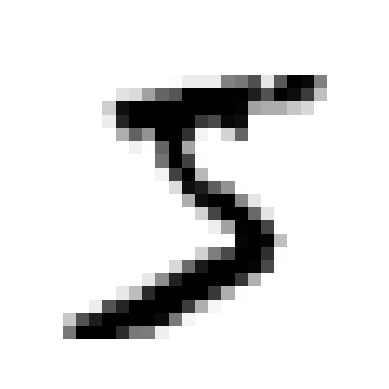

In [ ]:
# Let's look into the image
import matplotlib as mpl
import matplotlib.pyplot as plt

some_digit = X.values[0]
some_digit_image = some_digit.reshape(28 , 28)

plt.imshow(some_digit_image , cmap = mpl.cm.binary , interpolation = "nearest")
plt.axis("off")
plt.show()

In [ ]:
y[0]

'5'

In [ ]:
import numpy as np
y = y.astype(np.uint8)

In [ ]:
# Mnist already training and testing dataset

X_train , X_test , y_train , y_test = X[:60000] , X[60000:] , y[:60000] , y[60000:]


#**2. Training a Binary Classifier**

In [ ]:
# Let's make the dataset to predict only one digit (i.e., 5)
y_train_5 = (y_train == 5) # True for all 5s, False for all other digits.
y_test_5 = (y_test == 5)

In [ ]:
# Let's create a classifier
# Create Stochastic Gradient Descent (SGD) classifier

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state = 42)
sgd_clf.fit(X_train , y_train_5)

SGDClassifier(random_state=42)

In [ ]:
# let's detect the image
sgd_clf.predict([some_digit])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([ True])

#**3. Performance Measures**

There are many performance measures available, so get ready to learn many new concepts

##**3.1 - Measuring Accuracy Using Cross-Validation**

In [ ]:
# Implementing Cross-Validation

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits = 3 , random_state = 42, shuffle = True)

for train_index , test_index in skfolds.split(X_train , y_train_5):
  clone_clf = clone(sgd_clf)
  X_train_folds = X_train.iloc[train_index]
  y_train_folds = y_train_5.iloc[train_index]
  X_test_fold = X_train.iloc[test_index]
  y_test_fold = y_train_5.iloc[test_index]

  clone_clf.fit(X_train_folds, y_train_folds)
  y_pred = clone_clf.predict(X_test_fold)
  n_correct = sum(y_pred == y_test_fold)
  print(n_correct / len(y_pred)) # Accuracy score

0.9669
0.91625
0.96785


In [ ]:
# Let's use cross validation score from sklearn

from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf , X_train , y_train_5 , cv = 3 , scoring = "accuracy")

array([0.95035, 0.96035, 0.9604 ])

##**3.2 - Confusion Matrix**

In [ ]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf , X_train , y_train_5 , cv = 5)

In [ ]:
# Create the confusiong matrix
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_5 , y_train_pred)

array([[53115,  1464],
       [  916,  4505]])

In [ ]:
# Let's pretend to be perfect prediction
y_train_perfect_predictions = y_train_5
confusion_matrix(y_train_5 , y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

##**3.3 - Precision and Recall**

In [ ]:
from sklearn.metrics import precision_score , recall_score , f1_score
print("Precision : " , precision_score(y_train_5 , y_train_pred))
print("Recall    : " , recall_score(y_train_5 , y_train_pred))
print("F1 Score  : " , f1_score(y_train_5 , y_train_pred))

Precision :  0.7547327860613168
Recall    :  0.8310274857037447
F1 Score  :  0.7910447761194029


##**3.4 - Precision/Recall Tradeoff**

In [ ]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([2164.22030239])

In [ ]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

**Threshold** directly proportional to the **'precision'**

In [ ]:
threshold = 8000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [ ]:
# Calculate the decision scores
y_scores = cross_val_predict(sgd_clf , X_train , y_train_5 , cv = 3 ,
                             method = "decision_function")

With these scores , you can compute precision and recall for all possible threshold using the 'precision_recall_curve()' function:

In [ ]:
from sklearn.metrics import precision_recall_curve

precisions , recall , thresholds = precision_recall_curve(y_train_5 , y_scores)

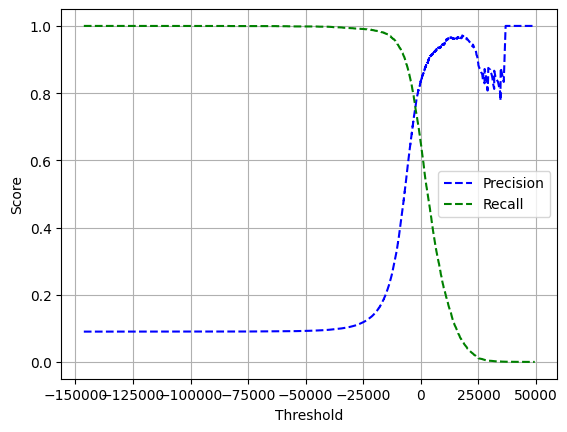

In [ ]:
def plot_precision_recall_vs_threshold(precisions , recall , thresholds):
  plt.plot(thresholds , precisions[:-1] , "b--" , label = "Precision")
  plt.plot(thresholds , recall[:-1] , "g--" , label = "Recall")

  plt.xlabel("Threshold")
  plt.ylabel("Score")
  plt.legend()
  plt.grid()

plot_precision_recall_vs_threshold(precisions , recall , thresholds)
plt.show()

In [ ]:
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]

y_train_pred_90 = (y_scores >= threshold_90_precision)
print("Precision Score : " , precision_score(y_train_5 , y_train_pred_90))
print("Recall Score    : " , recall_score(y_train_5 , y_train_pred_90))

Precision Score :  0.9000345901072293
Recall Score    :  0.4799852425751706


##**3.5 - The ROC Curve**

ROC curve - Receiver Operating characteristic Curve

In [ ]:
from sklearn.metrics import roc_curve

fpr , tpr , thresholds = roc_curve(y_train_5 , y_scores)

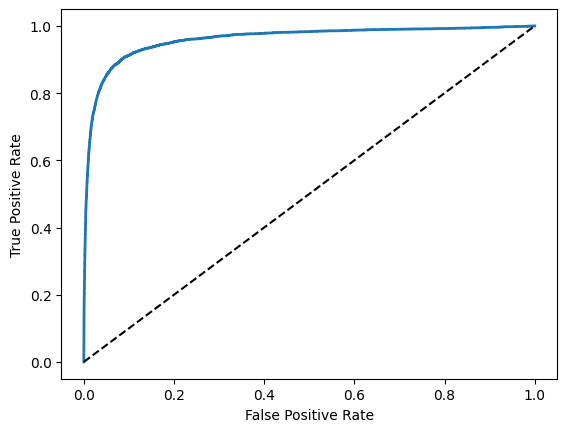

In [ ]:
def plot_roc_curve(fpr , tpr , label = None):
  plt.plot(fpr , tpr , linewidth = 2 , label = label)
  plt.plot([0 , 1] , [0 , 1] , 'k--')
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")

plot_roc_curve(fpr , tpr)
plt.show()

In [ ]:
# Calculate ROC AUC

from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5 , y_scores)

np.float64(0.9604938554008616)

In [ ]:
# Let's compare with Random Forest

from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state = 42)
y_probas_forest = cross_val_predict(forest_clf , X_train , y_train_5 , cv = 3 ,
                                    method = "predict_proba")

In [ ]:
y_scores_forest = y_probas_forest[:, 1]
fpr_forest , tpr_forest , thresholds_forest = roc_curve(y_train_5 , y_scores_forest)

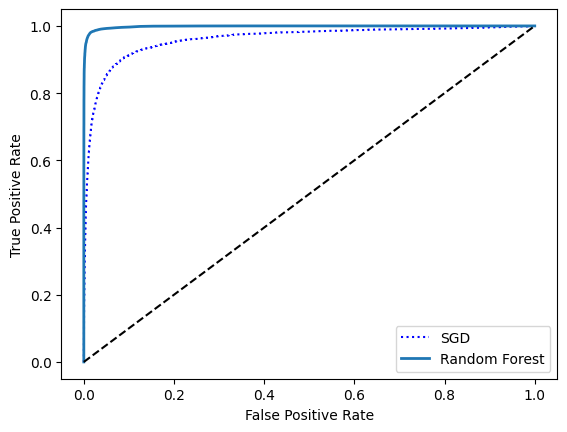

In [ ]:
plt.plot(fpr , tpr , "b:" , label = "SGD")
plot_roc_curve(fpr_forest , tpr_forest , "Random Forest")
plt.legend(loc = "lower right")
plt.show()

In [ ]:
roc_auc_score(y_train_5 , y_scores_forest)

np.float64(0.9983436731328145)

#**4. Multiclass Classification**

In [ ]:
# Train the model for multiclass classifier

sgd_clf.fit(X_train , y_train)
sgd_clf.predict([some_digit])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([3], dtype=uint8)

In [ ]:
some_digit_scores = sgd_clf.decision_function([some_digit])
some_digit_scores

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([[-31893.03095419, -34419.69069632,  -9530.63950739,
          1823.73154031, -22320.14822878,  -1385.80478895,
        -26188.91070951, -16147.51323997,  -4604.35491274,
        -12050.767298  ]])

In [ ]:
print(np.argmax(some_digit_scores))
print(sgd_clf.classes_)
print(sgd_clf.classes_[3])

3
[0 1 2 3 4 5 6 7 8 9]
3


In [ ]:
# Creating a multi-class classifier using OneVsOne Strategy

from sklearn.multiclass import OneVsOneClassifier
ovo_clf = OneVsOneClassifier(SGDClassifier(random_state = 42))
ovo_clf.fit(X_train , y_train)
print(ovo_clf.predict([some_digit]))
len(ovo_clf.estimators_)

[5]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneVsOneClassifier was fitted with feature names
  warnings.warn(


45

In [ ]:
# Training a RandomForestClassifier is just as easy

forest_clf.fit(X_train , y_train)
forest_clf.predict([some_digit])


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([5], dtype=uint8)

In [ ]:
forest_clf.predict_proba([some_digit])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([[0.  , 0.  , 0.01, 0.08, 0.  , 0.9 , 0.  , 0.  , 0.  , 0.01]])

In [ ]:
# evaluate using cross_val_score()
cross_val_score(sgd_clf , X_train , y_train , cv = 3 , scoring = "accuracy")

array([0.87365, 0.85835, 0.8689 ])

In [ ]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf , X_train_scaled , y_train , cv = 3 , scoring = "accuracy")

array([0.8983, 0.891 , 0.9018])

#**5. Error Analysis**

In [ ]:
# Construct confusion matrix by graphical way
y_train_pred = cross_val_predict(sgd_clf , X_train_scaled , y_train , cv = 3)
conf_mx = confusion_matrix(y_train , y_train_pred)
conf_mx

array([[5577,    0,   22,    5,    8,   43,   36,    6,  225,    1],
       [   0, 6400,   37,   24,    4,   44,    4,    7,  212,   10],
       [  27,   27, 5220,   92,   73,   27,   67,   36,  378,   11],
       [  22,   17,  117, 5227,    2,  203,   27,   40,  403,   73],
       [  12,   14,   41,    9, 5182,   12,   34,   27,  347,  164],
       [  27,   15,   30,  168,   53, 4444,   75,   14,  535,   60],
       [  30,   15,   42,    3,   44,   97, 5552,    3,  131,    1],
       [  21,   10,   51,   30,   49,   12,    3, 5684,  195,  210],
       [  17,   63,   48,   86,    3,  126,   25,   10, 5429,   44],
       [  25,   18,   30,   64,  118,   36,    1,  179,  371, 5107]])

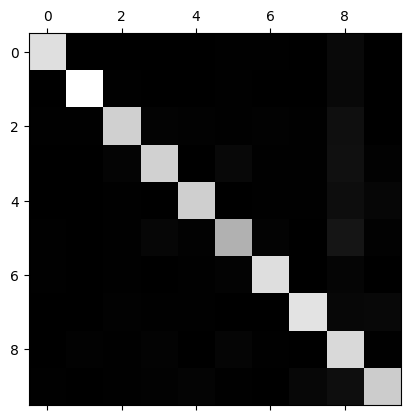

In [ ]:
# by matplotlib
plt.matshow(conf_mx , cmap = plt.cm.gray)
plt.show()

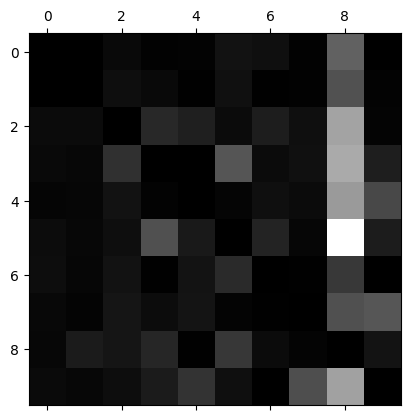

In [ ]:
# make the matrix more clear
row_sums = conf_mx.sum(axis = 1 , keepdims = True)
norm_conf_mx = conf_mx / row_sums

np.fill_diagonal(norm_conf_mx , 0)
plt.matshow(norm_conf_mx , cmap = plt.cm.gray)
plt.show()

#**6. Multilabel Classification**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_large , y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train , y_multilabel)

KNeighborsClassifier()

In [ ]:
knn_clf.predict([some_digit])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([[False,  True]])

In [88]:
y_train_knn_pred = cross_val_predict(knn_clf , X_train , y_multilabel , cv = 3)
f1_score(y_multilabel , y_train_knn_pred , average = "macro")

0.9764102655606048

#**7. Multioutput Classification**

In [89]:
noise = np.random.randint(0 , 100 , (len(X_train) , 784))
X_train_mod = X_train + noise
noise = np.random.randint(0 , 100 , (len(X_test) , 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


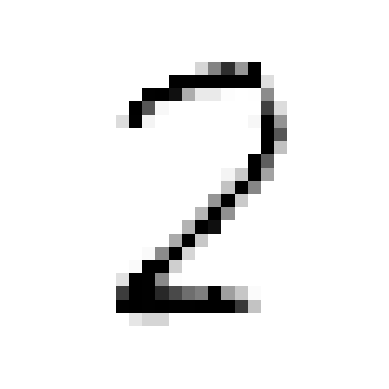

In [91]:
import numpy as np
some_index = np.random.randint(0, len(X_test_mod))

knn_clf.fit(X_train_mod , y_train_mod)
clean_digit = knn_clf.predict([X_test_mod.iloc[some_index]])

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")
    plt.show()

plot_digit(clean_digit)